In [2]:
#reading the lifestyle dataset
import pandas as pd
lifestyle_df = pd.read_csv("lifestyle_dataset_cleaned.tsv", sep="\t", encoding="utf-8")

In [3]:
#displaying first 5 rows
lifestyle_df.head()

,Age,Gender,Weight (kg),Height (m),Calories_Burned,Workout_Type,Water_Intake (liters),Workout_Frequency (days/week),BMI,Physical exercise,...,diet_type,sugar_g,sodium_mg,cholesterol_mg,cooking_method,Name of Exercise,Burns Calories (per 30 min),Body Part,Workout,BMI_calc
0,35,Male,65.27,1.62,1080.90,Strength,1.50,3.99,24.87,0.01,...,Vegan,31.77,1729.94,285.05,Grilled,Decline Push-ups,342.58,Legs,Dumbbell flyes,24.870447
1,23,Female,56.41,1.55,1809.91,HIIT,1.90,4.00,23.48,0.97,...,Vegetarian,12.34,693.08,300.61,Fried,Bear Crawls,357.16,Chest,Lateral raises,23.479709
2,33,Female,58.98,1.67,802.26,Cardio,1.88,2.99,21.15,-0.02,...,Paleo,42.81,2142.48,215.42,Boiled,Dips,359.63,Arms,Standing calf raises,21.148123
3,39,Female,93.78,1.70,1450.79,HIIT,2.50,3.99,32.45,0.04,...,Paleo,9.34,123.20,9.70,Fried,Mountain Climbers,351.65,Shoulders,Incline dumbbell flyes,32.449827
4,45,Male,52.42,1.88,1166.40,Strength,2.91,4.00,14.83,3.00,...,Vegan,23.78,1935.11,116.89,Baked,Bicep Curls,329.36,Abs,Military press,14.831372


In [4]:
#checking the  Dtype and missing values
lifestyle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            20000 non-null  int64  
 1   Gender                         20000 non-null  object 
 2   Weight (kg)                    20000 non-null  float64
 3   Height (m)                     20000 non-null  float64
 4   Calories_Burned                20000 non-null  float64
 5   Workout_Type                   20000 non-null  object 
 6   Water_Intake (liters)          20000 non-null  float64
 7   Workout_Frequency (days/week)  20000 non-null  float64
 8   BMI                            20000 non-null  float64
 9   Physical exercise              20000 non-null  float64
 10  Carbs                          20000 non-null  float64
 11  Proteins                       20000 non-null  float64
 12  Fats                           20000 non-null 

In [5]:
#checking the number of rows and columns
lifestyle_df.shape

(20000, 25)

In [6]:
#reading the sleep dataset
sleep_df = pd.read_csv(r'C:\Users\Lenovo\Downloads\sleep_and_health_dataset\Sleep_health_and_lifestyle_dataset.csv')

In [7]:
sleep_df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [8]:
#checking for the dtypes
sleep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [9]:
#merging the two datasets into single dataframe
df_all = pd.concat([lifestyle_df, sleep_df], ignore_index=True)


In [10]:
# Identify numeric and categorical columns separately, excluding "Age"
# because it is only a key variable and should not be aggregated.
import numpy as np
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Age"]   # keep age only as key

categorical_cols = df_all.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "Age"]


In [11]:
# Group by Age → one row per Age
result = []

for age, group in df_all.groupby("Age"):

    row = {"Age": age}

    #  A) Numeric columns → mean
    for col in numeric_cols:
        row[f"{col}_mean"] = group[col].mean()

    #  B) Categorical columns → percentage for each category
    for col in categorical_cols:
        total = len(group)

        for cat in group[col].dropna().unique():
            pct = (group[col] == cat).mean() * 100
            row[f"{col}_{cat}_pct"] = pct

    result.append(row)
df_final = pd.DataFrame(result)

In [12]:

df_final.head(43)


,Age,Weight (kg)_mean,Height (m)_mean,Calories_Burned_mean,Water_Intake (liters)_mean,Workout_Frequency (days/week)_mean,BMI_mean,Physical exercise_mean,Carbs_mean,Proteins_mean,...,Blood Pressure_121/79_pct,Blood Pressure_125/82_pct,Occupation_Salesperson_pct,Blood Pressure_135/90_pct,Blood Pressure_122/80_pct,Occupation_Manager_pct,Blood Pressure_142/92_pct,Blood Pressure_140/95_pct,Blood Pressure_139/91_pct,Blood Pressure_118/75_pct
0,18,74.069259,1.702662,1318.115570,2.516787,3.125380,25.712072,0.052034,234.986768,93.988555,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19,72.993968,1.735913,1271.317837,2.552480,3.273710,24.115873,0.241468,225.794008,90.290377,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20,85.378373,1.754026,1222.692141,2.644647,3.252120,27.486959,0.428522,252.432313,100.961456,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21,78.067317,1.723878,1362.453098,2.730146,3.270707,26.397244,0.563902,262.856488,105.171902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22,76.829945,1.721103,1313.515276,2.446526,3.502390,25.824063,0.352941,247.206728,98.922960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,23,76.029982,1.740055,1255.990219,2.657354,3.287080,24.797573,0.248431,232.986004,93.204580,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,24,63.223313,1.698632,1225.009970,2.491550,3.121641,21.909848,0.944316,268.482857,107.432918,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,25,72.234690,1.751557,1249.536379,2.416961,3.049456,23.398593,0.427355,253.274653,101.308574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,26,72.784894,1.678676,1267.880426,2.460426,3.172293,25.835721,0.324965,236.654704,94.659433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,27,80.159858,1.764943,1339.161790,2.809034,3.307869,25.955682,0.851108,257.065682,102.799943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
#checking the number of rows and columns
df_final.shape

(43, 204)

In [43]:
#checking if all unique age rows are merged properly
df_final['Age'].unique()

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60])

In [44]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Columns: 204 entries, Age to Blood Pressure_118/75_pct
dtypes: float64(203), int64(1)
memory usage: 68.7 KB


In [45]:
df_final.head(30)

,Age,Weight (kg)_mean,Height (m)_mean,Calories_Burned_mean,Water_Intake (liters)_mean,Workout_Frequency (days/week)_mean,BMI_mean,Physical exercise_mean,Carbs_mean,Proteins_mean,...,Blood Pressure_121/79_pct,Blood Pressure_125/82_pct,Occupation_Salesperson_pct,Blood Pressure_135/90_pct,Blood Pressure_122/80_pct,Occupation_Manager_pct,Blood Pressure_142/92_pct,Blood Pressure_140/95_pct,Blood Pressure_139/91_pct,Blood Pressure_118/75_pct
0,18,74.069259,1.702662,1318.115570,2.516787,3.125380,25.712072,0.052034,234.986768,93.988555,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19,72.993968,1.735913,1271.317837,2.552480,3.273710,24.115873,0.241468,225.794008,90.290377,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20,85.378373,1.754026,1222.692141,2.644647,3.252120,27.486959,0.428522,252.432313,100.961456,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,21,78.067317,1.723878,1362.453098,2.730146,3.270707,26.397244,0.563902,262.856488,105.171902,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22,76.829945,1.721103,1313.515276,2.446526,3.502390,25.824063,0.352941,247.206728,98.922960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,23,76.029982,1.740055,1255.990219,2.657354,3.287080,24.797573,0.248431,232.986004,93.204580,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,24,63.223313,1.698632,1225.009970,2.491550,3.121641,21.909848,0.944316,268.482857,107.432918,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,25,72.234690,1.751557,1249.536379,2.416961,3.049456,23.398593,0.427355,253.274653,101.308574,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,26,72.784894,1.678676,1267.880426,2.460426,3.172293,25.835721,0.324965,236.654704,94.659433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,27,80.159858,1.764943,1339.161790,2.809034,3.307869,25.955682,0.851108,257.065682,102.799943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#cleaning the merged dataset
# List of keywords to drop
drop_keywords = [
    "BMI_calc", 
    "Person ID",
    "Name of Exercise",
    "Blood Pressure_",
    "BMI Category_",
    "Workout_",
    "Body Part_",
    "Occupation_",
    "heart_rate_cat"
]
keep_columns=["Workout_Frequency (days/week)_mean"]

# Drop columns that contain any of these keywords
cols_to_drop = [col for col in df_final.columns if any(keyword in col for keyword in drop_keywords)
               and col not in keep_columns]

df_final = df_final.drop(columns=cols_to_drop)


In [14]:
#checking for the duplicates
print("Number of duplicate rows:", df_final.duplicated().sum())

df_final = df_final.drop_duplicates()
print("Duplicates removed. Shape:", df_final.shape)


Number of duplicate rows: 0
Duplicates removed. Shape: (43, 43)


In [15]:
df_final.head()

,Age,Weight (kg)_mean,Height (m)_mean,Calories_Burned_mean,Water_Intake (liters)_mean,Workout_Frequency (days/week)_mean,BMI_mean,Physical exercise_mean,Carbs_mean,Proteins_mean,...,diet_type_Vegetarian_pct,cooking_method_Baked_pct,cooking_method_Boiled_pct,cooking_method_Raw_pct,cooking_method_Steamed_pct,cooking_method_Fried_pct,cooking_method_Roasted_pct,cooking_method_Grilled_pct,Sleep Disorder_Sleep Apnea_pct,Sleep Disorder_Insomnia_pct
0,18,74.069259,1.702662,1318.115570,2.516787,3.125380,25.712072,0.052034,234.986768,93.988555,...,16.159696,12.927757,14.068441,14.448669,12.927757,14.828897,14.258555,16.539924,NaN,NaN
1,19,72.993968,1.735913,1271.317837,2.552480,3.273710,24.115873,0.241468,225.794008,90.290377,...,16.666667,13.293651,13.492063,12.103175,16.269841,14.285714,15.476190,15.079365,NaN,NaN
2,20,85.378373,1.754026,1222.692141,2.644647,3.252120,27.486959,0.428522,252.432313,100.961456,...,15.203426,14.989293,15.845824,14.346895,12.205567,13.062099,16.274090,13.276231,NaN,NaN
3,21,78.067317,1.723878,1362.453098,2.730146,3.270707,26.397244,0.563902,262.856488,105.171902,...,17.804878,17.073171,12.439024,14.634146,14.634146,13.902439,12.439024,14.878049,NaN,NaN
4,22,76.829945,1.721103,1313.515276,2.446526,3.502390,25.824063,0.352941,247.206728,98.922960,...,18.014706,14.889706,13.419118,15.992647,15.441176,13.786765,13.235294,13.235294,NaN,NaN


In [16]:
df_final.shape

(43, 43)

In [17]:
# Select all numeric columns and round their values to 2 decimal places
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
df_final[numeric_cols] = df_final[numeric_cols].round(2)


In [18]:
# Select numeric columns and fill any missing values with the median of each column
numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns

df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].median())


In [19]:
# Find all percentage columns (containing “_pct”) and replace their missing values with 0
pct_cols = [col for col in df_final.columns if "_pct" in col]

df_final[pct_cols] = df_final[pct_cols].fillna(0)


In [20]:
# Select categorical columns and fill missing values with "Unknown"
cat_cols = df_final.select_dtypes(include=['object']).columns

df_final[cat_cols] = df_final[cat_cols].fillna("Unknown")


In [21]:
#saving the changes 
df_final.to_csv(r"C:\Users\Lenovo\Downloads\merged_sleep_lifestyle_NEW_3.csv", index=False)


In [22]:
df_final.dtypes

Age                                     int64
Weight (kg)_mean                      float64
Height (m)_mean                       float64
Calories_Burned_mean                  float64
Water_Intake (liters)_mean            float64
Workout_Frequency (days/week)_mean    float64
BMI_mean                              float64
Physical exercise_mean                float64
Carbs_mean                            float64
Proteins_mean                         float64
Fats_mean                             float64
Calories_mean                         float64
sugar_g_mean                          float64
sodium_mg_mean                        float64
cholesterol_mg_mean                   float64
Burns Calories (per 30 min)_mean      float64
Sleep Duration_mean                   float64
Quality of Sleep_mean                 float64
Physical Activity Level_mean          float64
Stress Level_mean                     float64
Heart Rate_mean                       float64
Daily Steps_mean                  

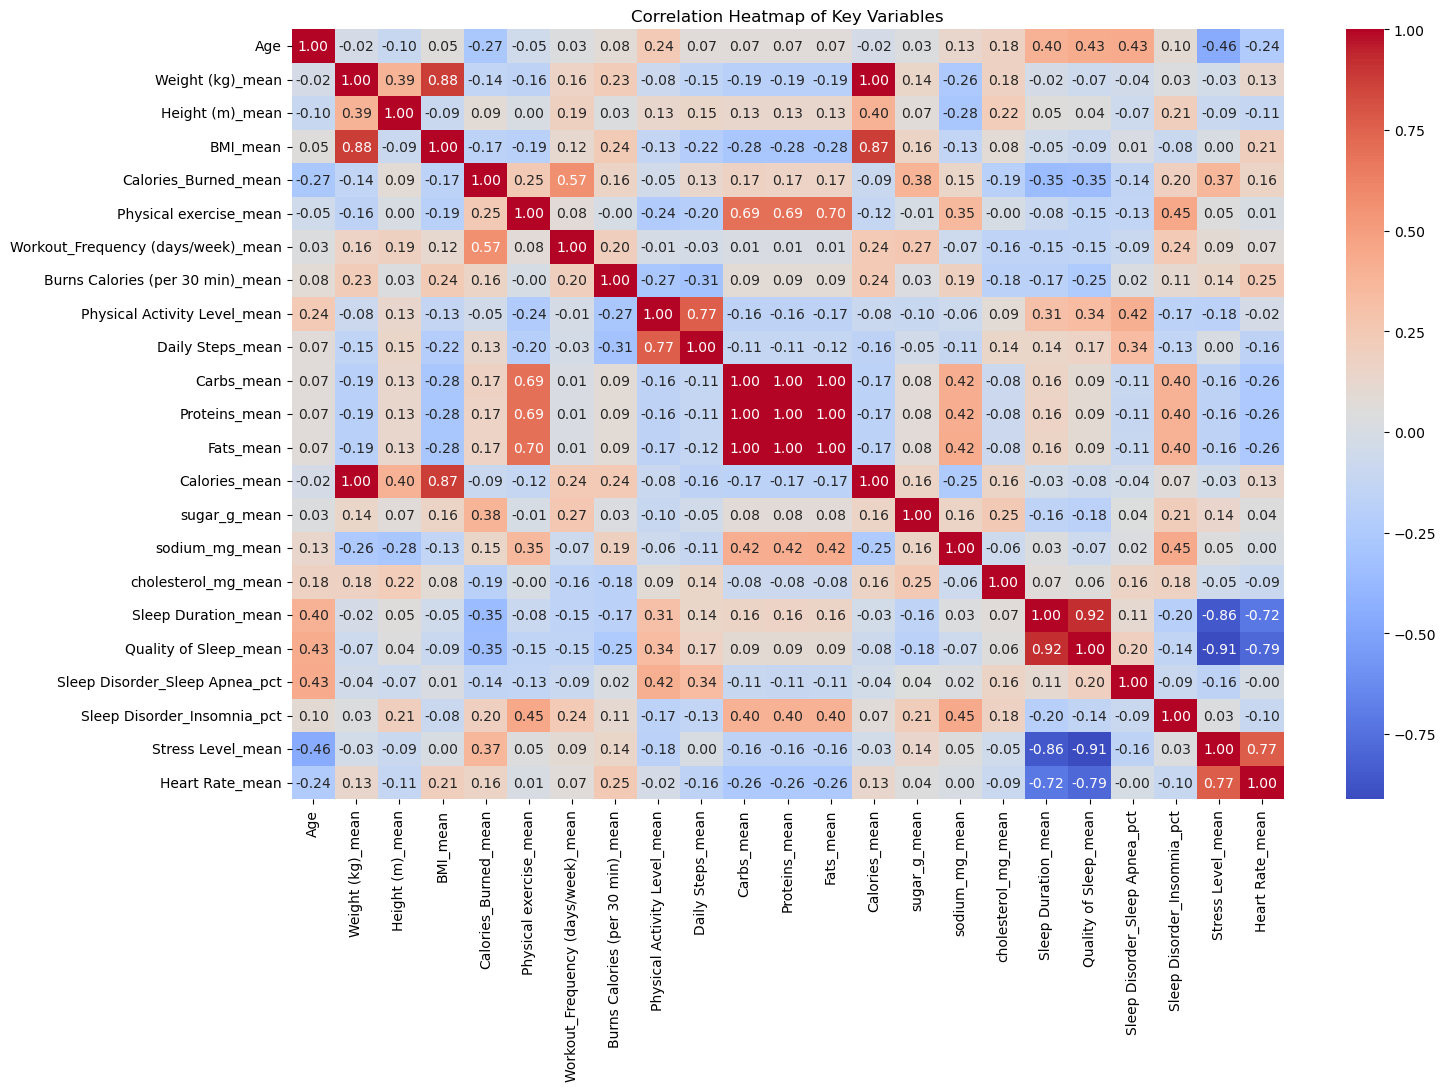

In [26]:
# Generate a correlation heatmap across all numeric columns
# This helps visualize the strength and direction of relationships
# and supports choosing Spearman for deeper analysis.
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'Age',
    'Weight (kg)_mean', 'Height (m)_mean', 'BMI_mean',

    'Calories_Burned_mean', 'Physical exercise_mean',
    'Workout_Frequency (days/week)_mean', 'Burns Calories (per 30 min)_mean',
    'Physical Activity Level_mean', 'Daily Steps_mean',

    'Carbs_mean', 'Proteins_mean', 'Fats_mean', 'Calories_mean',
    'sugar_g_mean', 'sodium_mg_mean', 'cholesterol_mg_mean',

    'Sleep Duration_mean', 'Quality of Sleep_mean',
    'Sleep Disorder_Sleep Apnea_pct', 'Sleep Disorder_Insomnia_pct',

    'Stress Level_mean', 'Heart Rate_mean'
]
plt.figure(figsize=(16, 10))
sns.heatmap(
    df_final[cols].corr(),
    annot=True,        
    fmt=".2f",         
    cmap='coolwarm'
)
plt.title("Correlation Heatmap of Key Variables")
plt.show()